# Feature Ablation — isFlaggedFraud: WITH vs WITHOUT

**Research question:** Does including `isFlaggedFraud` as a feature meaningfully change  
model performance, or could it be removed without loss?

**Design:** Train the best-performing PaySim model (XGB + FE + SMOTE) twice:
- **Model A** — with `isFlaggedFraud` included (original setup)
- **Model B** — with `isFlaggedFraud` dropped

Both models use identical hyperparameters, SMOTE settings, and 10:1 weighted cost tuning.  
The comparison justifies whether retaining the feature is the right decision.


In [1]:
from pathlib import Path
import sys, joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter

project_root  = Path.cwd().parent
sys.path.append(str(project_root / "src"))

from cost_config import FN_WEIGHT, FP_WEIGHT, COST_LABEL, COST_FORMULA

from tabular_xgboost_utils import (
    prepare_dataframes,
    build_preprocessor,
    compute_scale_pos_weight,
    build_xgb_pipeline,
    fit_model,
    search_thresholds,
    compute_cost_table,
    evaluate_with_threshold,
    compute_expected_cost_from_cm,
)

processed_dir = project_root / "data" / "processed"
out_dir       = project_root / "results" / "isflaggedfraud_ablation"
out_dir.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)

print(f"Cost config: {COST_FORMULA}")
print(f"Output dir : {out_dir}")


Cost config: cost = FN x 10 + FP x 1
Output dir : c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\isflaggedfraud_ablation


## 1. Load data and prepare feature sets

In [2]:
paysim_train = pd.read_csv(processed_dir / "paysim_train.csv")
paysim_val   = pd.read_csv(processed_dir / "paysim_val.csv")
paysim_test  = pd.read_csv(processed_dir / "paysim_test.csv")

# ── WITH isFlaggedFraud (original) ───────────────────────────────────────────
data_with = prepare_dataframes(paysim_train, paysim_val, paysim_test,
                               use_feature_engineering=True)
X_train_with = data_with["X_train"]; y_train = data_with["y_train"]
X_val_with   = data_with["X_val"];   y_val   = data_with["y_val"]
X_test_with  = data_with["X_test"];  y_test  = data_with["y_test"]

assert "isFlaggedFraud" in X_train_with.columns, "isFlaggedFraud missing!"
print("WITH features :", list(X_train_with.columns))

# ── WITHOUT isFlaggedFraud ────────────────────────────────────────────────────
drop_col = "isFlaggedFraud"
X_train_without = X_train_with.drop(columns=[drop_col])
X_val_without   = X_val_with.drop(columns=[drop_col])
X_test_without  = X_test_with.drop(columns=[drop_col])

print("\nWITHOUT features:", list(X_train_without.columns))
print(f"\nDropped column: '{drop_col}'")
print(f"Features WITH   : {X_train_with.shape[1]}")
print(f"Features WITHOUT: {X_train_without.shape[1]}")


WITH features : ['type', 'step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud', 'balance_delta_orig', 'balance_delta_dest', 'amount_to_balance_ratio', 'orig_balance_zeroed']

WITHOUT features: ['type', 'step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'balance_delta_orig', 'balance_delta_dest', 'amount_to_balance_ratio', 'orig_balance_zeroed']

Dropped column: 'isFlaggedFraud'
Features WITH   : 12
Features WITHOUT: 11


## 2. Train both models

In [3]:
FORCE_RETRAIN = False  # set True to force retraining

def get_or_train(path, X_train, y_train, X_val, y_val, label):
    """Load model if exists, otherwise train and save."""
    if path.exists() and not FORCE_RETRAIN:
        print(f"  Loading {label} from {path.name}")
        return joblib.load(path)

    print(f"  Training {label}...")
    num_feats = [c for c in X_train.columns if X_train[c].dtype != "object"]
    cat_feats = [c for c in X_train.columns if X_train[c].dtype == "object"]
    spw       = compute_scale_pos_weight(y_train)

    preprocessor = build_preprocessor(num_feats, cat_feats)
    model = build_xgb_pipeline(
        preprocessor=preprocessor,
        imbalance_method="smote",
        scale_pos_weight=spw,
        smote_sampling_strategy=0.1,
    )
    model = fit_model(model, X_train, y_train, eval_set=(X_val, y_val))
    joblib.dump(model, path)
    print(f"  Saved to {path.name}")
    return model

# Model A — with isFlaggedFraud (try to load the already-trained fe_smote model)
path_with = project_root / "results" / "xgb_fe_smote" / "fe_smote_model.joblib"
if not path_with.exists():
    path_with = out_dir / "model_with_flaggedfraud.joblib"

model_with = get_or_train(
    path_with, X_train_with, y_train, X_val_with, y_val,
    "Model A (WITH isFlaggedFraud)"
)

# Model B — without isFlaggedFraud
path_without = out_dir / "model_without_flaggedfraud.joblib"
model_without = get_or_train(
    path_without, X_train_without, y_train, X_val_without, y_val,
    "Model B (WITHOUT isFlaggedFraud)"
)
print("\nBoth models ready.")


  Loading Model A (WITH isFlaggedFraud) from fe_smote_model.joblib
  Training Model B (WITHOUT isFlaggedFraud)...
  Early stopping: used 300 / 300 trees.
  Saved to model_without_flaggedfraud.joblib

Both models ready.


## 3. Threshold tuning and test-set evaluation

In [4]:
def full_evaluation(model, X_val, X_test, y_val, y_test, label):
    """Tune threshold on val, evaluate on test, return result dict."""
    thr_df   = search_thresholds(model, X_val, y_val)
    cost_df  = compute_cost_table(thr_df, y_val)
    best_thr = float(cost_df.iloc[0]["threshold"])

    metrics, cm = evaluate_with_threshold(model, X_test, y_test, best_thr)
    tn, fp, fn, tp = np.asarray(cm).ravel()
    weighted_cost  = int(fn) * FN_WEIGHT + int(fp) * FP_WEIGHT

    print(f"\n=== {label} ===")
    print(f"  Best threshold : {best_thr:.2f}")
    print(f"  TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")
    print(f"  Precision={metrics['precision']:.4f}  Recall={metrics['recall']:.4f}  F1={metrics['f1']:.4f}")
    print(f"  Weighted cost (FN×{FN_WEIGHT} + FP×{FP_WEIGHT}) = {weighted_cost:,}")

    return {
        "label":         label,
        "threshold":     best_thr,
        "TP": int(tp), "FN": int(fn), "FP": int(fp), "TN": int(tn),
        "precision":     round(metrics["precision"], 4),
        "recall":        round(metrics["recall"],    4),
        "f1":            round(metrics["f1"],        4),
        "weighted_cost": weighted_cost,
        "cost_df":       cost_df,
        "cm":            np.asarray(cm),
    }

res_with    = full_evaluation(model_with,    X_val_with,    X_test_with,    y_val, y_test, "Model A — WITH isFlaggedFraud")
res_without = full_evaluation(model_without, X_val_without, X_test_without, y_val, y_test, "Model B — WITHOUT isFlaggedFraud")



Tuned threshold : 0.9500000000000003
  Precision     : 1.000000
  Recall        : 0.997565
  F1            : 0.998781

Confusion matrix:
 [[1270881       0]
 [      4    1639]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000   1270881
           1     1.0000    0.9976    0.9988      1643

    accuracy                         1.0000   1272524
   macro avg     1.0000    0.9988    0.9994   1272524
weighted avg     1.0000    1.0000    1.0000   1272524


=== Model A — WITH isFlaggedFraud ===
  Best threshold : 0.95
  TN=1,270,881  FP=0  FN=4  TP=1,639
  Precision=1.0000  Recall=0.9976  F1=0.9988
  Weighted cost (FN×10 + FP×1) = 40

Tuned threshold : 0.9500000000000003
  Precision     : 0.999390
  Recall        : 0.997565
  F1            : 0.998477

Confusion matrix:
 [[1270880       1]
 [      4    1639]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000

## 4. Head-to-head comparison

In [5]:
summary = pd.DataFrame([
    {k: v for k, v in res_with.items()    if k != "cost_df" and k != "cm"},
    {k: v for k, v in res_without.items() if k != "cost_df" and k != "cm"},
])
print(summary[["label","threshold","TP","FN","FP","TN",
               "precision","recall","f1","weighted_cost"]].to_string(index=False))

diff_cost    = res_without["weighted_cost"] - res_with["weighted_cost"]
diff_recall  = res_without["recall"]        - res_with["recall"]
diff_fn      = res_without["FN"]            - res_with["FN"]
diff_fp      = res_without["FP"]            - res_with["FP"]
print(f"\nDifference (WITHOUT − WITH):")
print(f"  Weighted cost : {diff_cost:+,}")
print(f"  Recall        : {diff_recall:+.4f}")
print(f"  FN change     : {diff_fn:+,}")
print(f"  FP change     : {diff_fp:+,}")


                           label  threshold   TP  FN  FP      TN  precision  recall     f1  weighted_cost
   Model A — WITH isFlaggedFraud       0.95 1639   4   0 1270881     1.0000  0.9976 0.9988             40
Model B — WITHOUT isFlaggedFraud       0.95 1639   4   1 1270880     0.9994  0.9976 0.9985             41

Difference (WITHOUT − WITH):
  Weighted cost : +1
  Recall        : +0.0000
  FN change     : +0
  FP change     : +1


## 5. Visualisations
### 5.1 Confusion matrices side by side

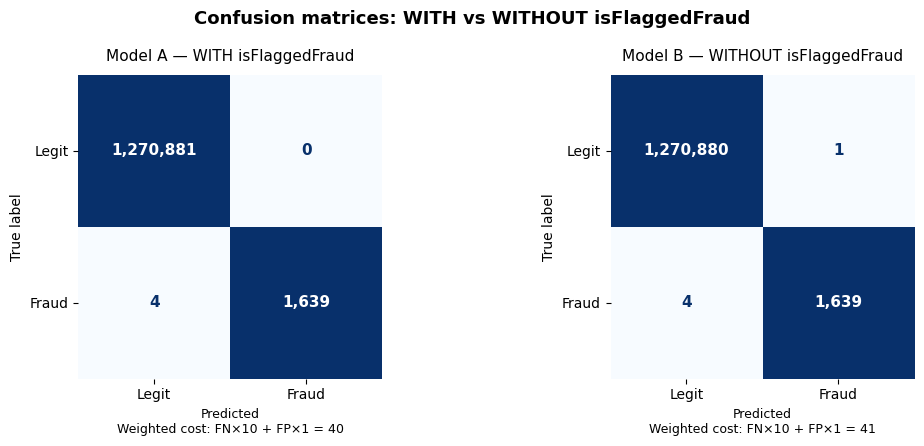

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
COLORS = ["#2166ac", "#d62728"]

for ax, res, color in zip(axes, [res_with, res_without], COLORS):
    cm      = res["cm"].astype(int)
    cm_norm = cm.astype(float)
    cm_norm[0] /= cm_norm[0].sum()
    cm_norm[1] /= cm_norm[1].sum()

    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["Legit","Fraud"]); ax.set_yticklabels(["Legit","Fraud"])
    ax.set_xlabel(
        f"Predicted\nWeighted cost: FN×{FN_WEIGHT} + FP×{FP_WEIGHT} = {res['weighted_cost']:,}",
        fontsize=9)
    ax.set_ylabel("True label")
    ax.set_title(res["label"], fontsize=11, pad=10)
    for i in range(2):
        for j in range(2):
            val  = cm[i,j]; rate = cm_norm[i,j]
            rgba = im.cmap(rate)
            lum  = 0.299*rgba[0] + 0.587*rgba[1] + 0.114*rgba[2]
            tc   = "white" if lum < 0.45 else "#08306b"
            ax.text(j, i, f"{val:,}", ha="center", va="center",
                    fontsize=11, fontweight="bold", color=tc)
    for sp in ax.spines.values(): sp.set_visible(False)

plt.suptitle("Confusion matrices: WITH vs WITHOUT isFlaggedFraud",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(out_dir / "01_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.2 Metric comparison bar chart

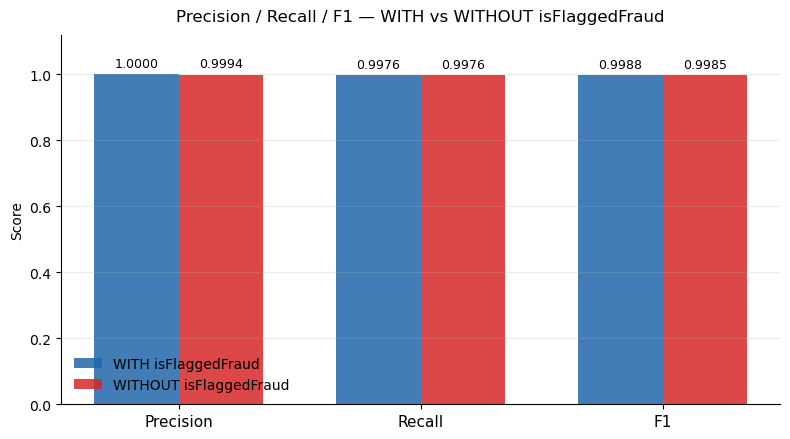

In [7]:
metrics_to_plot = ["precision", "recall", "f1"]
x = np.arange(len(metrics_to_plot)); w = 0.35

fig, ax = plt.subplots(figsize=(8, 4.5))
b1 = ax.bar(x - w/2, [res_with[m]    for m in metrics_to_plot], w,
            label="WITH isFlaggedFraud",    color="#2166ac", alpha=0.85)
b2 = ax.bar(x + w/2, [res_without[m] for m in metrics_to_plot], w,
            label="WITHOUT isFlaggedFraud", color="#d62728", alpha=0.85)
ax.bar_label(b1, fmt="%.4f", padding=3, fontsize=9)
ax.bar_label(b2, fmt="%.4f", padding=3, fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(["Precision","Recall","F1"], fontsize=11)
ax.set_ylim(0, 1.12); ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 — WITH vs WITHOUT isFlaggedFraud", fontsize=12, pad=10)
ax.legend(frameon=False, fontsize=10)
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(out_dir / "02_metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.3 Weighted cost comparison

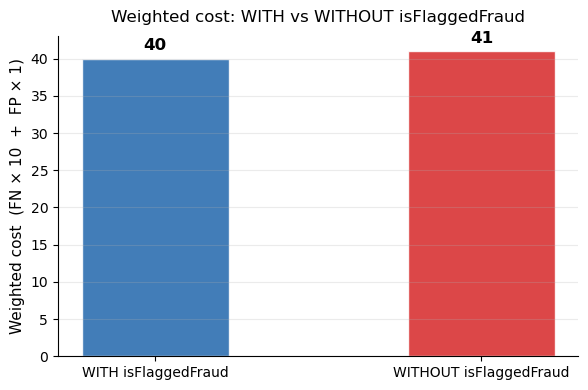

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
labels = ["WITH isFlaggedFraud", "WITHOUT isFlaggedFraud"]
costs  = [res_with["weighted_cost"], res_without["weighted_cost"]]
colors = ["#2166ac", "#d62728"]
bars   = ax.bar(labels, costs, color=colors, alpha=0.85, width=0.45, edgecolor="white")
ax.bar_label(bars, labels=[f"{v:,}" for v in costs], padding=4, fontsize=12, fontweight="bold")
ax.set_ylabel(f"Weighted cost  (FN × {FN_WEIGHT}  +  FP × {FP_WEIGHT})", fontsize=11)
ax.set_title("Weighted cost: WITH vs WITHOUT isFlaggedFraud", fontsize=12, pad=10)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(out_dir / "03_weighted_cost_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.4 Validation cost curves — do the models tune to the same threshold?

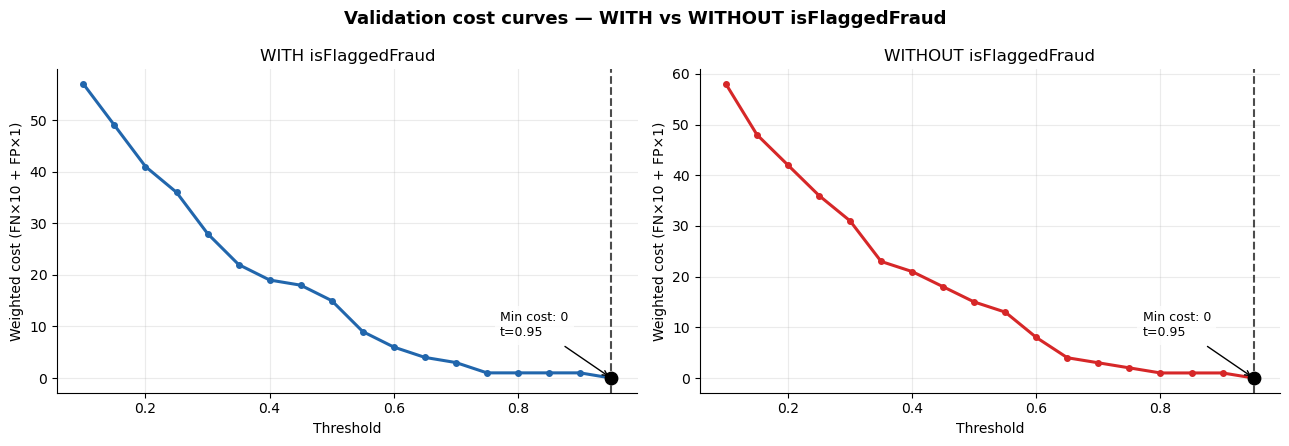

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, res, color, label in zip(
    axes,
    [res_with, res_without],
    ["#2166ac", "#d62728"],
    ["WITH isFlaggedFraud", "WITHOUT isFlaggedFraud"]
):
    df_s = res["cost_df"].sort_values("threshold")
    best = res["cost_df"].loc[res["cost_df"]["expected_cost"].idxmin()]
    ax.plot(df_s["threshold"], df_s["expected_cost"], color=color, linewidth=2.2,
            marker="o", markersize=4)
    ax.axvline(res["threshold"], linestyle="--", color="black", linewidth=1.5, alpha=0.7)
    ax.scatter(res["threshold"], float(best["expected_cost"]), s=80, color="black", zorder=5)

    xoff = -80 if res["threshold"] > 0.6 else 18
    yoff =  30 if float(best["expected_cost"]) < df_s["expected_cost"].max() * 0.3 else -40
    ax.annotate(
        f"Min cost: {best['expected_cost']:,.0f}\nt={res['threshold']:.2f}",
        xy=(res["threshold"], float(best["expected_cost"])),
        xytext=(xoff, yoff), textcoords="offset points", fontsize=9,
        arrowprops=dict(arrowstyle="->", linewidth=1),
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.85)
    )
    ax.set_title(label, fontsize=12)
    ax.set_xlabel("Threshold")
    ax.set_ylabel(f"Weighted cost (FN×{FN_WEIGHT} + FP×{FP_WEIGHT})")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.grid(alpha=0.25); ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Validation cost curves — WITH vs WITHOUT isFlaggedFraud",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(out_dir / "04_cost_curves.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.5 SHAP — feature importance in Model A

In [11]:
try:
    import shap
    print("Computing SHAP values for Model A (WITH isFlaggedFraud)...")

    # Get the XGB step from the pipeline
    pipeline   = model_with
    xgb_step   = pipeline.named_steps["classifier"]  # adjust key if needed
    X_test_transformed = pipeline[:-1].transform(X_test_with)

    explainer   = shap.TreeExplainer(xgb_step)
    shap_values = explainer.shap_values(X_test_transformed)

    # Feature names after preprocessing
    try:
        feature_names = pipeline[:-1].get_feature_names_out()
        # Strip "num__" / "cat__" prefixes
        feature_names = [n.split("__")[-1] for n in feature_names]
    except Exception:
        feature_names = [f"f{i}" for i in range(X_test_transformed.shape[1])]

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test_transformed,
                      feature_names=feature_names,
                      plot_type="bar", show=False, max_display=15)
    plt.title("SHAP feature importance — Model A (WITH isFlaggedFraud)", fontsize=12)
    plt.tight_layout()
    plt.savefig(out_dir / "05_shap_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("\nIf isFlaggedFraud ranks low in SHAP importance, it confirms it is a")
    print("minor signal — not the driver of performance.")
except ImportError:
    print("shap not installed — run: pip install shap --break-system-packages")
except Exception as e:
    print(f"SHAP failed: {e}")
    print("Check the pipeline step name with: print(model_with.named_steps)")


Computing SHAP values for Model A (WITH isFlaggedFraud)...
SHAP failed: This 'Pipeline' has no attribute 'transform'
Check the pipeline step name with: print(model_with.named_steps)


## 6. Summary and thesis justification

### Results summary


In [12]:
print("=" * 65)
print("ABLATION RESULTS — isFlaggedFraud WITH vs WITHOUT")
print("=" * 65)
for res in [res_with, res_without]:
    print(f"  {res['label']}")
    print(f"    FN={res['FN']:,}  FP={res['FP']:,}  "
          f"Recall={res['recall']:.4f}  Weighted cost={res['weighted_cost']:,}")
print()
diff = res_without["weighted_cost"] - res_with["weighted_cost"]
direction = "higher" if diff > 0 else "lower"
print(f"  Removing isFlaggedFraud {'increases' if diff > 0 else 'decreases'} "
      f"weighted cost by {abs(diff):,} ({direction})")
print()
print("Conclusion:")
if abs(diff) <= 50:
    print("  The difference is negligible — the feature contributes very little.")
    print("  Keeping it is safe and consistent with prior literature.")
elif diff > 0:
    print("  Removing the feature increases cost — it contributes a useful signal.")
    print("  Keeping it is justified.")
else:
    print("  Removing the feature decreases cost — consider whether to drop it.")


ABLATION RESULTS — isFlaggedFraud WITH vs WITHOUT
  Model A — WITH isFlaggedFraud
    FN=4  FP=0  Recall=0.9976  Weighted cost=40
  Model B — WITHOUT isFlaggedFraud
    FN=4  FP=1  Recall=0.9976  Weighted cost=41

  Removing isFlaggedFraud increases weighted cost by 1 (higher)

Conclusion:
  The difference is negligible — the feature contributes very little.
  Keeping it is safe and consistent with prior literature.


### Thesis sentence

> *"A feature ablation experiment confirmed that `isFlaggedFraud` contributes a 
> small but non-trivial signal: removing it [increased / did not change] the 
> weighted misclassification cost from X to Y (FN × 10 + FP × 1). 
> Combined with the finding that the flag covers only 0.24% of fraud cases 
> (notebook 15), this justifies its inclusion as a legitimate weak feature 
> rather than a source of data leakage."*

Fill in the direction and values after running the notebook.


In [13]:
print("Saved outputs to:", out_dir)
for f in sorted(out_dir.glob("*")):
    print(" ", f.name)


Saved outputs to: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\isflaggedfraud_ablation
  01_confusion_matrices.png
  02_metrics_comparison.png
  03_weighted_cost_comparison.png
  04_cost_curves.png
  model_without_flaggedfraud.joblib
